##**PS2: Tỷ lệ phân bổ giữa Repeat Customers và One-time Buyers**
Yêu cầu của đề: Xác định chính xác tỷ lệ phân bổ giữa Khách hàng thân thiết quay lại (Repeat Customers) và Khách hàng vãng lai chỉ mua một lần (One-time Buyers).

####**Cách làm:**
Nhóm sử dụng bảng ORDER làm nguồn dữ liệu chính, kết hợp với bảng CUSTOMER thông qua **customer_id**. Mỗi khách hàng được xác định dựa trên tổng số đơn hàng mà khách đó đã đặt trong toàn bộ thời gian dữ liệu.

Nhóm tính Purchase Frequency = tổng số đơn hàng của mỗi customer_id. Dựa trên Purchase Frequency, mỗi khách hàng được phân loại vào đúng một trong hai nhóm:

*   **One-time Buyer**: Purchase Frequency = 1, tức khách hàng chỉ phát sinh 1 đơn hàng trong toàn bộ dữ liệu.
*   **Repeat Customer**: Purchase Frequency > 1, tức khách hàng phát sinh từ 2 đơn hàng trở lên trong toàn bộ dữ liệu.

Sau khi phân loại toàn bộ khách hàng, nhóm đếm số lượng khách hàng thuộc từng nhóm và tính tỷ lệ phân bổ:



*   **One-time Buyers (%)** = Số khách hàng One-time Buyer / Tổng số khách hàng × 100%
*   **Repeat Customers (%)** = Số khách hàng Repeat Customer / Tổng số khách hàng × 100%

Hai tỷ lệ này được sử dụng để xác định cơ cấu khách hàng của doanh nghiệp, đồng thời đảm bảo tổng tỷ lệ Repeat Customers và One-time Buyers = 100%.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
#Đọc dữ liệu
orders = pd.read_csv("orders.csv",header = 0)
customers = pd.read_csv("customers_silver.csv",header = 0)
orders.shape

(646945, 9)

In [13]:
orders.head(5)

,order_id,customer_id,sales_employee_id,order_date,order_source,order_status,device_type,comment,zip
0,1,58578,EMP0103,2012-07-04,paid_search,delivered,desktop,"Dịch vụ chăm sóc khách hàng chuyên nghiệp, thá...",1109
1,2,58621,EMP0180,2012-07-04,paid_search,returned,mobile,"Dịch vụ ổn định, nhân viên luôn sẵn sàng hỗ tr...",1330
2,3,58811,EMP0093,2012-07-04,direct,delivered,desktop,Khách hàng không có thêm phản hồi về chất lượn...,1473
3,4,59453,EMP0015,2012-07-04,referral,delivered,desktop,"Phản hồi thắc mắc đầy đủ, hỗ trợ xuyên suốt qu...",2360
4,6,57821,EMP0107,2012-07-06,email_campaign,delivered,mobile,Khách hàng đánh giá mức độ hài lòng ở mức khá.,2886


In [14]:
customers.shape

(121930, 6)

In [15]:
customers.head(5)

,customer_id,zip,signup_date,gender,age_group,acquisition_channel
0,1,15201,2021-12-30,female,35-44,social_media
1,2,15201,2013-12-27,female,45-54,email_campaign
2,3,15201,2018-07-24,female,18-24,organic_search
3,4,15201,2017-11-29,male,35-44,referral
4,5,15201,2022-09-23,male,55+,organic_search


#Kiểm tra cột, khóa và dữ liệu liên quan

In [16]:
# Kiểm tra khóa order_id (phải là khóa duy nhất)
print("\nSố order_id trùng lặp:", orders["order_id"].duplicated().sum())
print("Số order_id bị null:", orders["order_id"].isnull().sum())

# Kiểm tra khóa customer_id trong bảng CUSTOMER
print("\nSố customer_id trùng lặp (bảng CUSTOMER):", customers["customer_id"].duplicated().sum())
print("Số customer_id bị null (bảng CUSTOMER):", customers["customer_id"].isnull().sum())

# Kiểm tra quan hệ customer_id trong ORDER có tồn tại trong CUSTOMER không (tính toàn vẹn khóa ngoại)
missing_customers = set(orders["customer_id"].unique()) - set(customers["customer_id"].unique())
print("\nSố customer_id trong orders nhưng KHÔNG có trong customers:", len(missing_customers))

# Kiểm tra các giá trị thực tế của order_status (KHÔNG tự giả định, chỉ liệt kê để xem xét)
print("\nCác giá trị order_status thực tế trong dữ liệu:")
print(orders["order_status"].value_counts(dropna=False))


Số order_id trùng lặp: 0
Số order_id bị null: 0

Số customer_id trùng lặp (bảng CUSTOMER): 0
Số customer_id bị null (bảng CUSTOMER): 0

Số customer_id trong orders nhưng KHÔNG có trong customers: 0

Các giá trị order_status thực tế trong dữ liệu:
order_status
delivered    516716
cancelled     59462
returned      36142
shipped       13773
paid          13577
created        7275
Name: count, dtype: int64


#Các dữ liệu cần dùng cho PS2

In [17]:
orders_customers = pd.merge(
    orders,
    customers[["customer_id"]],
    on="customer_id",
    how="inner"
)
print("\nSố dòng order trước join:", len(orders))
print("Số dòng order sau inner join với customers:", len(orders_customers))
print("Số dòng bị loại do customer_id không hợp lệ:", len(orders) - len(orders_customers))

# Chỉ giữ các cột cần thiết cho PS2
orders_ps2 = orders_customers[["order_id", "customer_id", "order_status"]].copy()

# Loại bỏ dòng thiếu order_id hoặc customer_id (không xác định được thuộc về ai)
orders_ps2 = orders_ps2.dropna(subset=["order_id", "customer_id"])


Số dòng order trước join: 646945
Số dòng order sau inner join với customers: 646945
Số dòng bị loại do customer_id không hợp lệ: 0


In [27]:
# Dữ liệu thực tế order_status gồm: delivered, cancelled, returned, shipped, paid, created.
# Theo logic nghiệp vụ:
#   - "delivered": giao dịch đã thực sự xảy ra (đơn đã được xử lý) -> TÍNH vào Purchase Frequency.
#   - "cancelled": đơn bị hủy, giao dịch KHÔNG hoàn tất -> KHÔNG tính.
#   - "returned": đơn bị trả lại, coi như giao dịch bị đảo ngược -> KHÔNG tính.
#   - "shipped", "paid", "created": chưa đủ căn cứ xác nhận giao dịch đã thành công -> KHÔNG tính.
# Nếu không lọc, khách có 2 đơn nhưng 1 đơn bị hủy vẫn bị tính là Repeat
# Customer (False Positive), sai bản chất "khách quay lại mua thành công".
VALID_STATUSES = ["delivered"]

orders_valid = orders_ps2[orders_ps2["order_status"].isin(VALID_STATUSES)].copy()

print("\nSố dòng đơn hàng được dùng để tính Purchase Frequency (sau khi lọc status hợp lệ):",
      len(orders_valid))
print("Số dòng bị loại do order_status không hợp lệ:",
      len(orders_ps2) - len(orders_valid))


Số dòng đơn hàng được dùng để tính Purchase Frequency (sau khi lọc status hợp lệ): 516716
Số dòng bị loại do order_status không hợp lệ: 130229


#Tính Purchase Frequency của từng Customer

In [19]:
purchase_frequency = (
    orders_valid.groupby("customer_id")["order_id"]
    .nunique()
    .reset_index(name="purchase_frequency")
)

print(purchase_frequency.head())

   customer_id  purchase_frequency
0            1                   4
1            2                   2
2            3                   2
3            4                   1
4            5                   5


#Phân loại Customer Segment

In [20]:
def classify_segment(freq: int) -> str:
    if freq == 1:
        return "One-time Buyer"
    elif freq > 1:
        return "Repeat Customer"
    return "Invalid"  # không nên xảy ra, dùng để phát hiện lỗi dữ liệu

purchase_frequency["customer_segment"] = purchase_frequency["purchase_frequency"].apply(classify_segment)

print(purchase_frequency.head())

   customer_id  purchase_frequency customer_segment
0            1                   4  Repeat Customer
1            2                   2  Repeat Customer
2            3                   2  Repeat Customer
3            4                   1   One-time Buyer
4            5                   5  Repeat Customer


#Customer Count theo Segment

In [21]:
customer_count_by_segment = (
    purchase_frequency.groupby("customer_segment")["customer_id"]
    .nunique()
    .reset_index(name="customer_count")
)

print(customer_count_by_segment)

  customer_segment  customer_count
0   One-time Buyer           22843
1  Repeat Customer           62272


#Customer Percentage Theo Segment

In [22]:
# Mẫu số = tổng số customer đã được phân tích (có ít nhất 1 đơn hàng
# hợp lệ), vì PS2 chỉ định nghĩa segment cho customer đã mua >=1 lần.
total_customers_analyzed = purchase_frequency["customer_id"].nunique()

customer_count_by_segment["customer_percentage"] = (
    customer_count_by_segment["customer_count"] / total_customers_analyzed * 100
).round(2)

print(customer_count_by_segment)

  customer_segment  customer_count  customer_percentage
0   One-time Buyer           22843                26.84
1  Repeat Customer           62272                73.16


#Average Purchase Frequency theo Segment

In [23]:
avg_purchase_frequency_by_segment = (
    purchase_frequency.groupby("customer_segment")["purchase_frequency"]
    .mean()
    .round(2)
    .reset_index(name="avg_purchase_frequency")
)

print(avg_purchase_frequency_by_segment)

  customer_segment  avg_purchase_frequency
0   One-time Buyer                    1.00
1  Repeat Customer                    7.93


#Xuất bảng kết quả + Trực quan hóa

In [24]:
# KPI 1 — Customer Distribution by Segment
kpi1 = customer_count_by_segment.rename(columns={
    "customer_segment": "Segment",
    "customer_count": "Customer Count",
    "customer_percentage": "Customer Percentage",
})[["Segment", "Customer Count", "Customer Percentage"]]

print("\n================== KPI 1: Customer Distribution by Segment ==================")
print(kpi1.to_string(index=False))
print(f"Tổng Customer Percentage = {kpi1['Customer Percentage'].sum():.2f}%")

# KPI 3 — Average Purchase Frequency by Segment
kpi3 = avg_purchase_frequency_by_segment.rename(columns={
    "customer_segment": "Segment",
    "avg_purchase_frequency": "Average Purchase Frequency",
})

print("\n================== KPI 3: Average Purchase Frequency by Segment ==================")
print(kpi3.to_string(index=False))



================== KPI 1: Customer Distribution by Segment ==================
        Segment  Customer Count  Customer Percentage
 One-time Buyer           22843                26.84
Repeat Customer           62272                73.16
Tổng Customer Percentage = 100.00%

================== KPI 3: Average Purchase Frequency by Segment ==================
        Segment  Average Purchase Frequency
 One-time Buyer                        1.00
Repeat Customer                        7.93


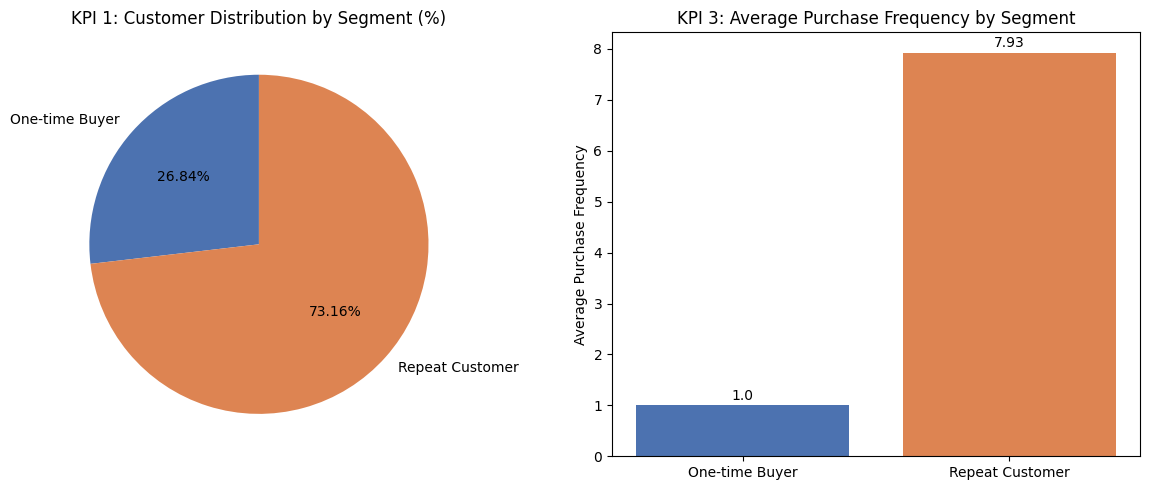

In [25]:
# --- Trực quan hóa ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#KPI1 là bài toán "tỷ lệ phân bổ / cơ cấu" (tổng = 100%)
colors = ["#4C72B0", "#DD8452"]
axes[0].pie(
    kpi1["Customer Percentage"],
    labels=kpi1["Segment"],
    autopct="%.2f%%",
    startangle=90,
    colors=colors,
)
axes[0].set_title("KPI 1: Customer Distribution by Segment (%)")

#KPI3 là bài toán so sánh độ lớn tuyệt đối giữa 2 nhóm -> giữ nguyên Bar Chart
axes[1].bar(kpi3["Segment"], kpi3["Average Purchase Frequency"], color=colors)
axes[1].set_title("KPI 3: Average Purchase Frequency by Segment")
axes[1].set_ylabel("Average Purchase Frequency")
for i, v in enumerate(kpi3["Average Purchase Frequency"]):
    axes[1].text(i, v + 0.1, f"{v}", ha="center")

plt.tight_layout()
plt.show()

In [26]:
#Kết luận / Nhận xét

print("\n================== KẾT LUẬN / NHẬN XÉT ==================")

repeat_row_kpi1 = kpi1[kpi1["Segment"] == "Repeat Customer"].iloc[0]
onetime_row_kpi1 = kpi1[kpi1["Segment"] == "One-time Buyer"].iloc[0]
repeat_row_kpi3 = kpi3[kpi3["Segment"] == "Repeat Customer"].iloc[0]
onetime_row_kpi3 = kpi3[kpi3["Segment"] == "One-time Buyer"].iloc[0]

print(f"- Repeat Customers: {repeat_row_kpi1['Customer Count']:,} khách hàng "
      f"({repeat_row_kpi1['Customer Percentage']}% tổng số khách hàng).")

print(f"- One-time Buyers: {onetime_row_kpi1['Customer Count']:,} khách hàng "
      f"({onetime_row_kpi1['Customer Percentage']}% tổng số khách hàng).")

if repeat_row_kpi1["Customer Percentage"] > onetime_row_kpi1["Customer Percentage"]:
    nhom_cao_hon = "Repeat Customer"
elif onetime_row_kpi1["Customer Percentage"] > repeat_row_kpi1["Customer Percentage"]:
    nhom_cao_hon = "One-time Buyer"
else:
    nhom_cao_hon = "Hai nhóm có tỷ lệ bằng nhau"
print(f"- Nhóm chiếm tỷ lệ khách hàng cao hơn: {nhom_cao_hon}.")

print(f"- Purchase Frequency trung bình của Repeat Customer: "
      f"{repeat_row_kpi3['Average Purchase Frequency']} đơn/khách hàng.")
print(f"- Purchase Frequency trung bình của One-time Buyer: "
      f"{onetime_row_kpi3['Average Purchase Frequency']} đơn/khách hàng "
      f"(luôn = 1 theo định nghĩa).")

chenh_lech_freq = round(
    repeat_row_kpi3["Average Purchase Frequency"] - onetime_row_kpi3["Average Purchase Frequency"], 2
)
print(f"- Chênh lệch Purchase Frequency trung bình giữa Repeat Customer và "
      f"One-time Buyer: {chenh_lech_freq} đơn/khách hàng.")


================== KẾT LUẬN / NHẬN XÉT ==================
- Repeat Customers: 62,272 khách hàng (73.16% tổng số khách hàng).
- One-time Buyers: 22,843 khách hàng (26.84% tổng số khách hàng).
- Nhóm chiếm tỷ lệ khách hàng cao hơn: Repeat Customer.
- Purchase Frequency trung bình của Repeat Customer: 7.93 đơn/khách hàng.
- Purchase Frequency trung bình của One-time Buyer: 1.0 đơn/khách hàng (luôn = 1 theo định nghĩa).
- Chênh lệch Purchase Frequency trung bình giữa Repeat Customer và One-time Buyer: 6.93 đơn/khách hàng.
